In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix

In [2]:
transform = transforms.ToTensor()

In [3]:
train_data = datasets.CIFAR10(root='../Data',train=True,download=True,transform=transform)

Files already downloaded and verified


In [4]:
test_data = datasets.CIFAR10(root='../Data',train=False,download=True,transform=transform)

Files already downloaded and verified


In [5]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [7]:
train_loader = DataLoader(train_data,batch_size=10,shuffle=True)

In [8]:
test_loader = DataLoader(test_data,batch_size=10,shuffle=False)

In [9]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32,64,3,1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64,128,3,1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.fc1 = nn.Linear(2*2*128,300)
        self.fc2 = nn.Linear(300,100)
        self.fc3 = nn.Linear(100,10)
        
        self.dropout = nn.Dropout(0.5)

    def forward(self,X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.bn3(self.conv3(X)))
        X = F.max_pool2d(X,2,2)
        X = X.view(-1,2*2*128)
        X = self.dropout(F.relu(self.fc1(X)))
        X = self.dropout(F.relu(self.fc2(X)))
        X = self.fc3(X)
        return F.log_softmax(X,dim=1)

In [10]:
torch.manual_seed(13)
model=ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=512, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [12]:
import time
start_time = time.time()

epochs = 10
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0

    for b,(X_train,y_train) in enumerate(train_loader):
        b+=1

        y_pred = model(X_train)
        loss = criterion(y_pred,y_train)

        predicted = torch.max(y_pred.data,1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr+=batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%1250 == 0:
            print(f" epoch: {i:2} batch: {b:4}  [{10*b:6}/50000] loss: {loss.item():10.8f} accuracy: {trn_corr.item()*100/(10*b):7.3f}%")

    train_correct.append(trn_corr.item())
    train_losses.append(loss.item())

    with torch.no_grad():
        for b,(X_test,y_test) in enumerate(test_loader):
            y_val = model(X_test)

            predicted = torch.max(y_val.data,1)[1]
            tst_corr += (predicted == y_test).sum()

        loss = criterion(y_val,y_test)
        test_correct.append(tst_corr.item())
        test_losses.append(loss.item())



print(f"\nDuration {time.time() - start_time:.0f}seconds")

 epoch:  0 batch: 1250  [ 12500/50000] loss: 1.57974362 accuracy:  28.216%
 epoch:  0 batch: 2500  [ 25000/50000] loss: 1.57647324 accuracy:  33.864%
 epoch:  0 batch: 3750  [ 37500/50000] loss: 1.23298097 accuracy:  37.635%
 epoch:  0 batch: 5000  [ 50000/50000] loss: 1.13154781 accuracy:  40.172%
 epoch:  1 batch: 1250  [ 12500/50000] loss: 1.31322885 accuracy:  51.384%
 epoch:  1 batch: 2500  [ 25000/50000] loss: 1.00836504 accuracy:  52.296%
 epoch:  1 batch: 3750  [ 37500/50000] loss: 1.05731452 accuracy:  53.152%
 epoch:  1 batch: 5000  [ 50000/50000] loss: 0.72581130 accuracy:  53.914%
 epoch:  2 batch: 1250  [ 12500/50000] loss: 1.94447875 accuracy:  58.640%
 epoch:  2 batch: 2500  [ 25000/50000] loss: 0.60888612 accuracy:  58.636%
 epoch:  2 batch: 3750  [ 37500/50000] loss: 0.60395116 accuracy:  59.184%
 epoch:  2 batch: 5000  [ 50000/50000] loss: 0.94695693 accuracy:  59.602%
 epoch:  3 batch: 1250  [ 12500/50000] loss: 1.02193642 accuracy:  62.848%
 epoch:  3 batch: 2500  [

Text(0.5, 1.0, 'Losses')

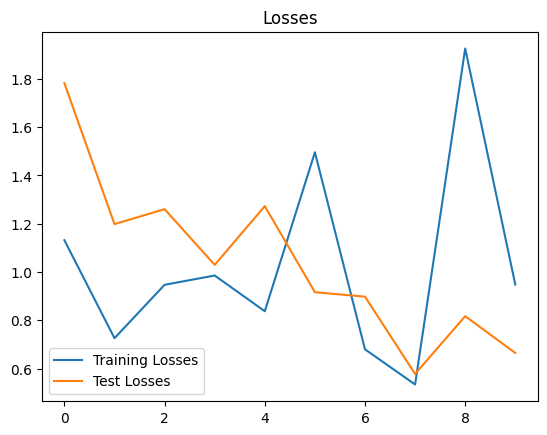

In [14]:
plt.plot(train_losses, label="Training Losses")
plt.plot(test_losses, label="Test Losses")
plt.legend()
plt.title("Losses")

Text(0.5, 1.0, 'Accuracy')

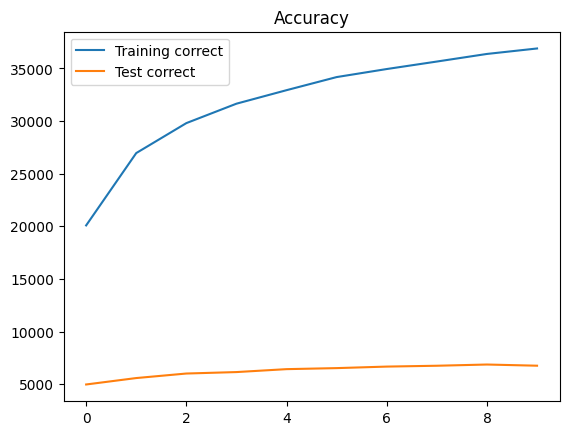

In [15]:
plt.plot(train_correct, label="Training correct")
plt.plot(test_correct, label="Test correct")
plt.legend()
plt.title("Accuracy")

In [17]:
print(f"Training Accuracy: {train_correct[-1]/500:.2f}%")
print(f"Test Accuracy: {test_correct[-1]/100:.2f}%")

Training Accuracy: 73.78%
Test Accuracy: 67.64%
